# Player Analytics
This project is about analyzing players that I used during my FIFA/EAFC Career modes since FIFA 12.

This specific Notebook is about analyzing the weight and height of players.

In [4]:
# Basic settings for the notebook
import matplotlib.pyplot as plt
import seaborn as sns
import sys

project_root = r"C:\Users\Martijn\PycharmProjects\CareerLegacy"

if project_root not in sys.path:
    sys.path.append(project_root)

from Analytics.AnalyticsTooling import AnalyticsTooling

# Generic Tooling for analytics
analytic_tools = AnalyticsTooling()

In [5]:
# Get the dataframes
dataframe_dict = analytic_tools.dataframes
df_person_info = dataframe_dict["df_person_info"]
df_career_modes = dataframe_dict["df_career_modes"]

## Short introduction of the database

In [8]:
print(f"[i] {len(df_person_info)} unique players where used.")
print(f"[i] Players with {df_person_info["country_uuid"].nunique()} unique nationalities.")
print(f"[i] I have managed {df_career_modes["club_uuid"].nunique()} different clubs in {df_person_info["career_mode_uuid"].nunique()} career modes.")

[i] 657 unique players where used.
[i] Players with 71 unique nationalities.
[i] I have managed 12 different clubs in 17 career modes.


# Height and Weight Analysis
During this analysis I want to get an insight on the following questions:
- What is the maximum, minimum and average height of all players
- What is the maximum, minimum and average weight of all players
- Is there a relation between height and weight of a player?

--- Height statistics ---
[!] The shortest player is  Bernard with 163cm.
[!] The tallest player is Furghill Vink with 203cm.
[!] The average height is 180cm.
--- Weight statistics ---
[!] The lightest player is  Bernard with 57kg.
[!] The heaviest player is Manuel Neuer with 92kg.
[!] The average weight is 73kg.
--- Relation between weight and height ---
[i] Height and weight correlation value is: 0.8061964673642503
[i] This is a strong positive relation.
[i] The p-value is 1.9424255744539824e-151
[i] This means height and weight are statistically significant.


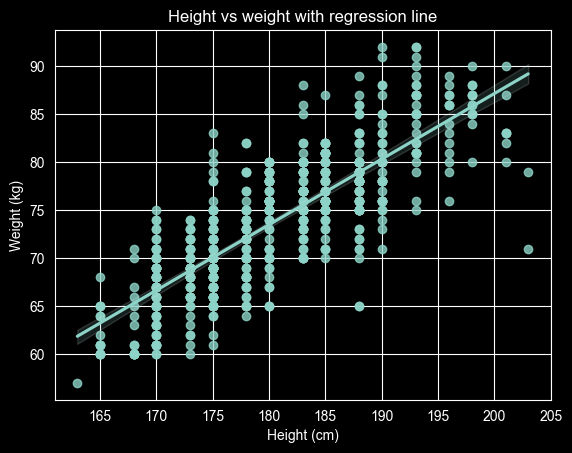

In [7]:
# Height statistics
shortest_player = df_person_info.loc[df_person_info["height_cm"].idxmin()]
tallest_player = df_person_info.loc[df_person_info["height_cm"].idxmax()]
print("--- Height statistics ---")
print(f"[!] The shortest player is {shortest_player["first_name"]} {shortest_player["last_name"]} with {shortest_player['height_cm']}cm.")
print(f"[!] The tallest player is {tallest_player["first_name"]} {tallest_player["last_name"]} with {tallest_player['height_cm']}cm.")
print(f"[!] The average height is {int(df_person_info["height_cm"].mean())}cm.")

# Weight statistics
lightest_player = df_person_info.loc[df_person_info["weight_kg"].idxmin()]
heaviest_player = df_person_info.loc[df_person_info["weight_kg"].idxmax()]
print("--- Weight statistics ---")
print(f"[!] The lightest player is {lightest_player["first_name"]} {lightest_player["last_name"]} with {lightest_player['weight_kg']}kg.")
print(f"[!] The heaviest player is {heaviest_player["first_name"]} {heaviest_player["last_name"]} with {heaviest_player['weight_kg']}kg.")
print(f"[!] The average weight is {int(df_person_info["weight_kg"].mean())}kg.")

# Relation between weight and height
# Statistic calculations
print("--- Relation between weight and height ---")
analytic_tools.get_correlation_value(("Height", df_person_info["height_cm"]), ("Weight", df_person_info["weight_kg"]))
analytic_tools.get_p_value(("Height", df_person_info["height_cm"]), ("Weight", df_person_info["weight_kg"]))

# Graph
sns.regplot(x="height_cm", y="weight_kg", data=df_person_info)
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs weight with regression line")
plt.show()